# Model

In [1]:
from topological_insulator import Problem

structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "kagome.json"

problem = Problem(structure_path=structure_path, structure_name=structure_name
)

In [ ]:
import numpy as np

def set_eigenvalues(problem:Problem, Delta_SOC=0.0, t_1=-1, x=[]):
    sublattice_labels = ["A", "B", "C", "D", "E", "F"]
    cell = problem.cell_parser
    g = cell.geometry
    n_subs = len(g.delta_vectors.value)
    subs = sublattice_labels[:n_subs]
    # Chosen occupancies for net spin == 0
    for label_i in subs:
        if label_i == "A":
            n_px_up = x[1]
            n_px_down = x[2]
            n_py_up = x[3]
            n_py_down = x[4]
            n_pz_up = x[5]
            n_pz_down = x[6]
        elif label_i == "B":
            n_px_up = x[7]
            n_px_down = x[8]
            n_py_up = x[9]
            n_py_down = x[10]
            n_pz_up = x[11]
            n_pz_down = x[12]
        else:
            n_px_up = x[13]
            n_px_down = x[14]
            n_py_up = x[15]
            n_py_down = x[16]
            n_pz_up = x[17]
            n_pz_down = x[18]
        parser = getattr(problem.cell_parser.eigenvalues, label_i).value
        parser["chadi_soc"][label_i]["Delta_pp"] = Delta_SOC
        parser["onsite_energy"][label_i]["E_s"] = -5
        parser["interaction"][label_i]["U_p"] = x[0]
        parser["interaction"][label_i]["n_px_up"] = n_px_up
        parser["interaction"][label_i]["n_px_down"] = n_px_down
        parser["interaction"][label_i]["n_py_up"] = n_py_up
        parser["interaction"][label_i]["n_py_down"] = n_py_down
        parser["interaction"][label_i]["n_pz_up"] = n_pz_up
        parser["interaction"][label_i]["n_pz_down"] = n_pz_down
        # Off-Diagonal Values
        for label_j in subs:
            # Hoppings
            try:
                parser["nn_hopping"][label_j]["t_ss_sigma"] = 0.01 * np.abs(t_1)
                # parser["nn_hopping"][label_j]["t_sp_sigma"] = 1
                parser["nn_hopping"][label_j]["t_pp_sigma"] = t_1
                parser["nn_hopping"][label_j]["t_pp_pi"] = t_1/2
            except:
                pass
        # print(parser)   
x = [
        3,
        0., 0, 0., 0, 0, 1,
        0.0, 0, 0.0, 0, 1, 0,
        0., 0, 0., 0.0, 0, 1,
]
set_eigenvalues(problem, -0.2, -1, x)

In [3]:
location = "edge"
problem.setup(
    N_r = 20, # size of lattice in real space
    N_k = 300, # reciprocal space discretization
    location = location,
    BZ="extended"
)

Building Geometry...
Geometry - Done.
Building 'Edge' Hamiltonian...
'Edge' Hamiltonian - Done.


In [4]:
g = problem.geometry
tb_edge = problem.hamiltonian[location]["tight_binding"]

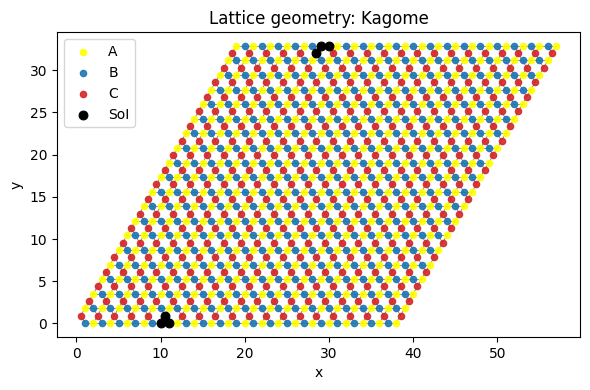

In [5]:
edge_sites = [0, 1, 2, -3, -2, -1]
g.plot_lattice(tb_edge.sublattice_idxs[edge_sites])

In [6]:
problem.run(
    H_type="reciprocal"
)

Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done!


In [7]:
bands = [i for i in range(58, 231)]

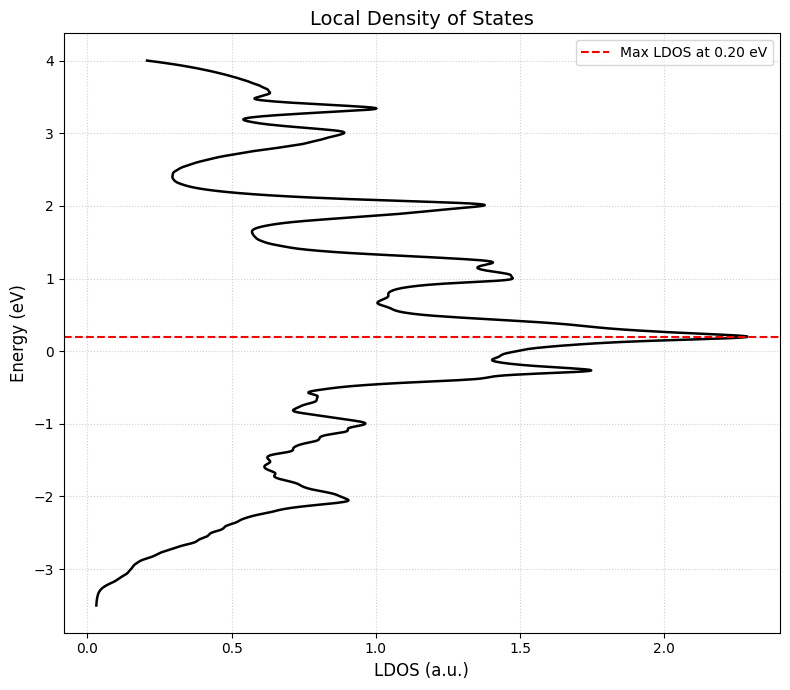

In [21]:
invariants = problem.hamiltonian["edge"]["topological_invariants"]
LDOS, E = invariants.get_local_density_of_states(
    site_idx = 0,
    E_max = 4,#8, 
    E_min = -3.5,#-12,
    eta = 0.05
)

invariants.plot_density_of_states(LDOS, E)

In [24]:
import numpy as np
edge_bands_top = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=0.0, threshold=0.12)
edge_bands_bot_left = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=0.0, threshold=0.2)
edge_bands_bot_right = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=0.0, threshold=0.2)
edge_bands = np.unique(np.concatenate([edge_bands_top, edge_bands_bot_left, edge_bands_bot_right]))
print(edge_bands)

[ 3 19 37]


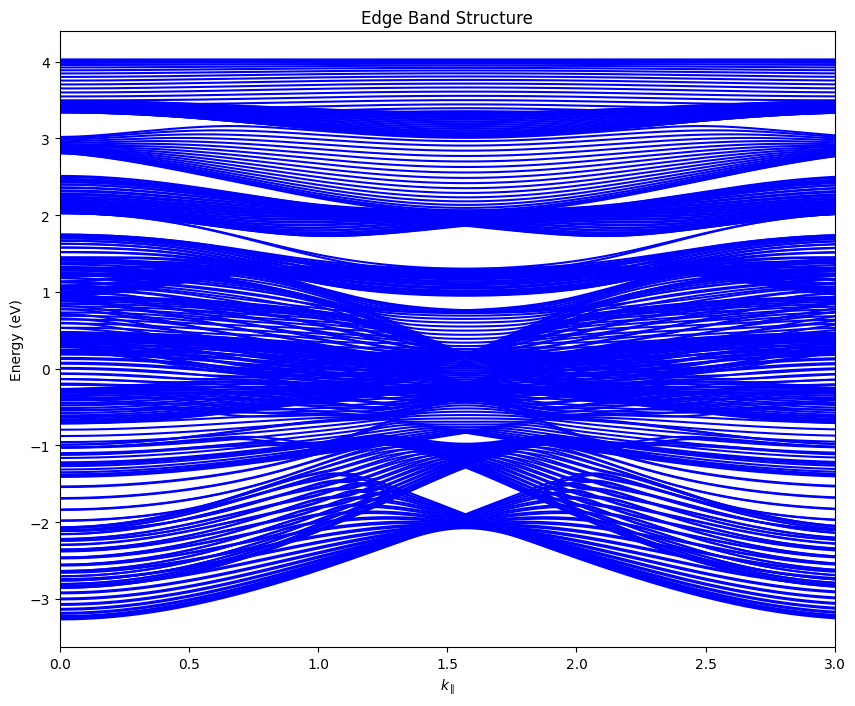

In [22]:
tb_edge.plot_dispersion(g, bands = [i for i in range(120, 472)], x_max=3, x_min=0)

Total norm: 1.000000


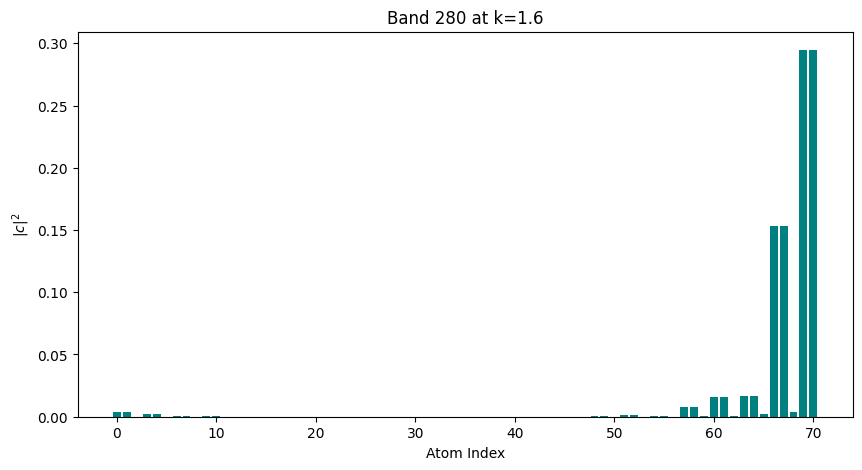

Total norm: 1.000000


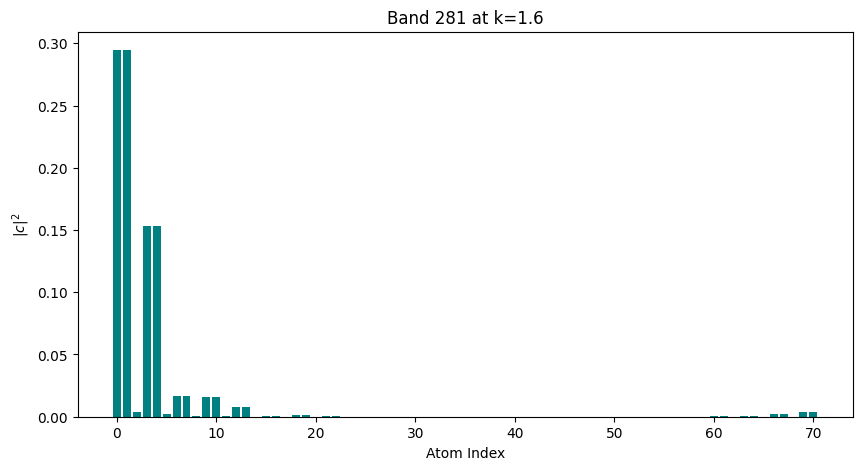

Total norm: 1.000000


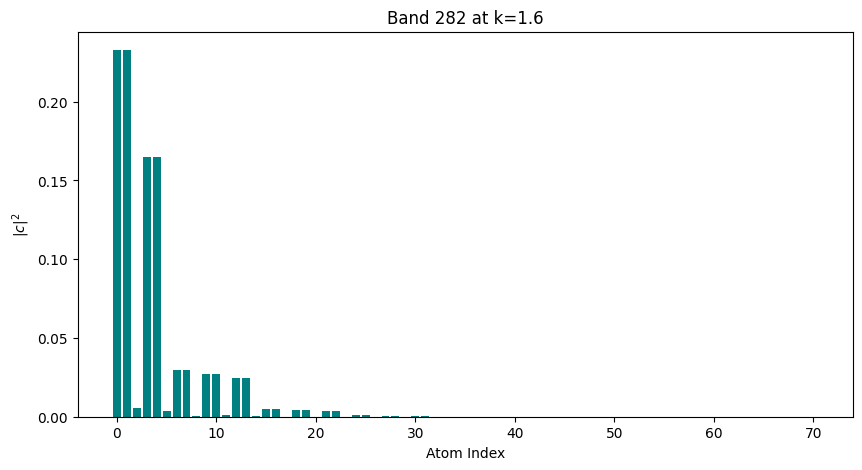

Total norm: 1.000000


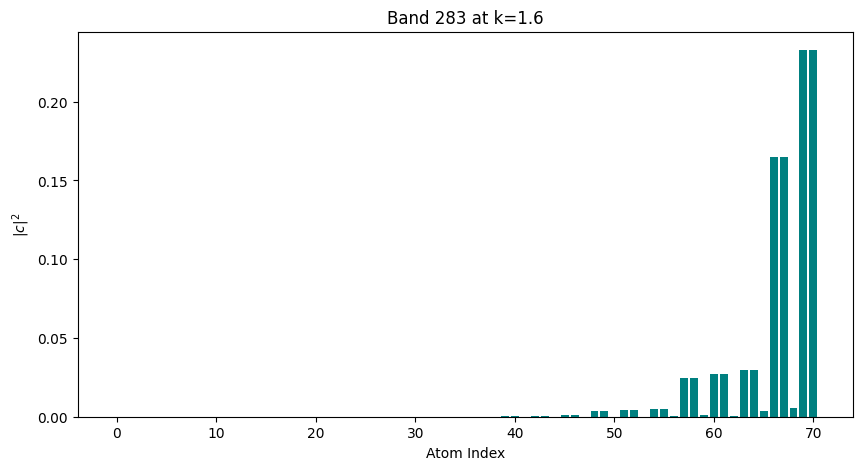

Total norm: 1.000000


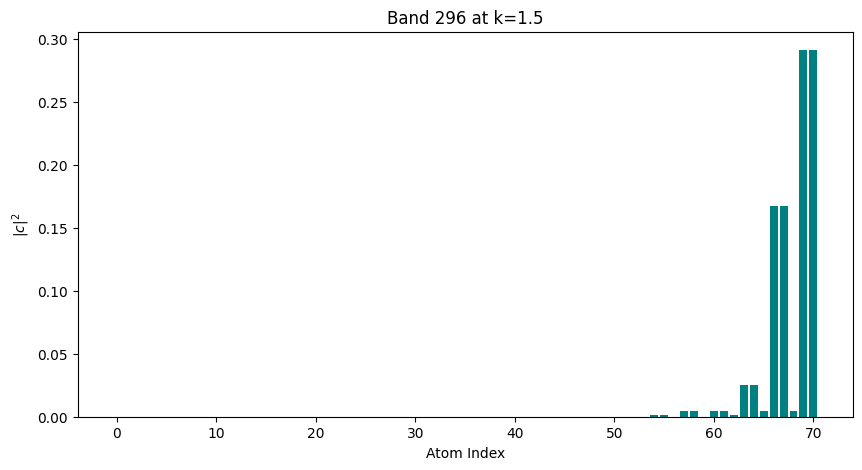

Total norm: 1.000000


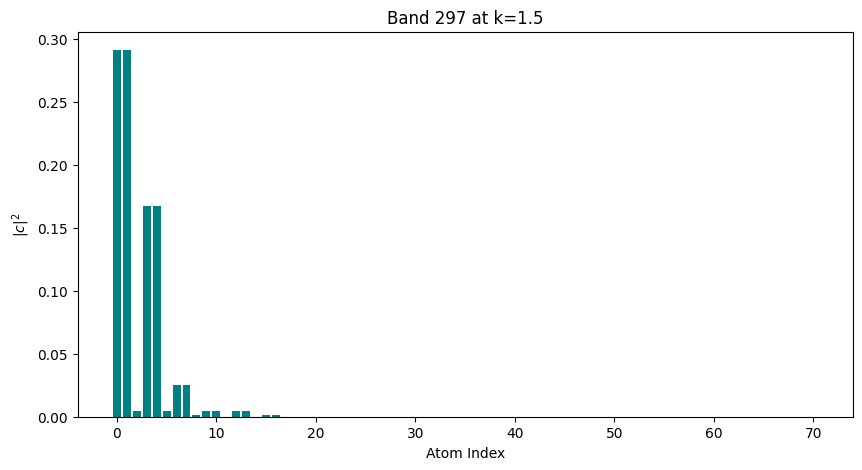

Total norm: 1.000000


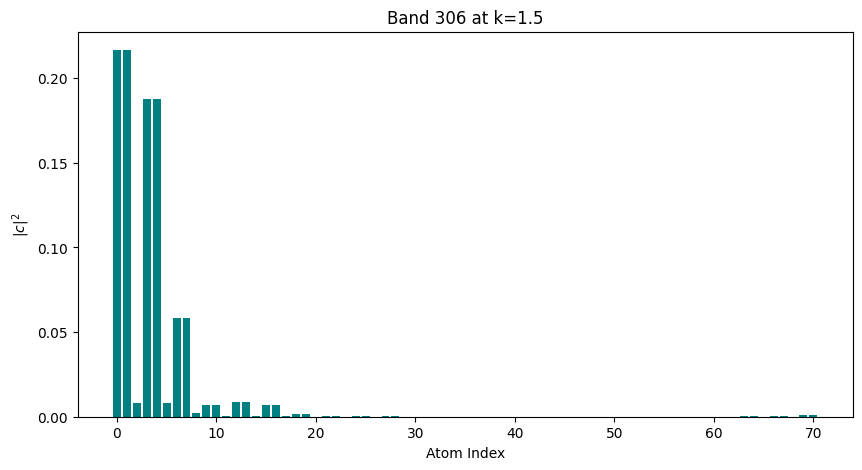

Total norm: 1.000000


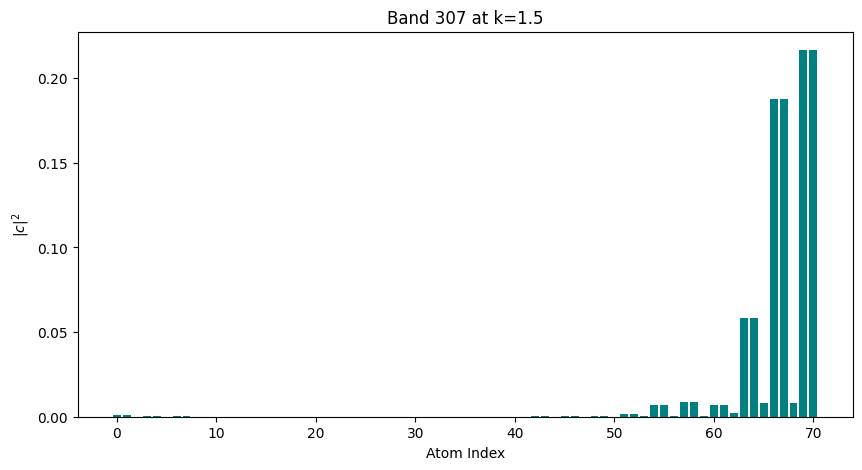

Total norm: 1.000000


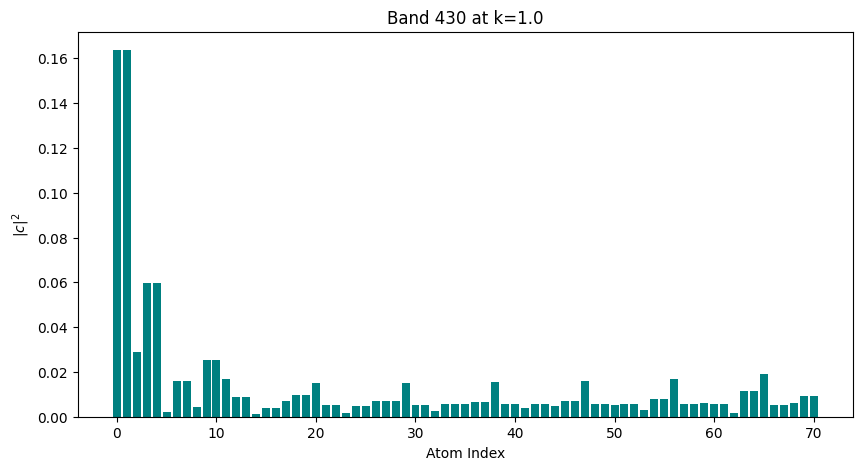

Total norm: 1.000000


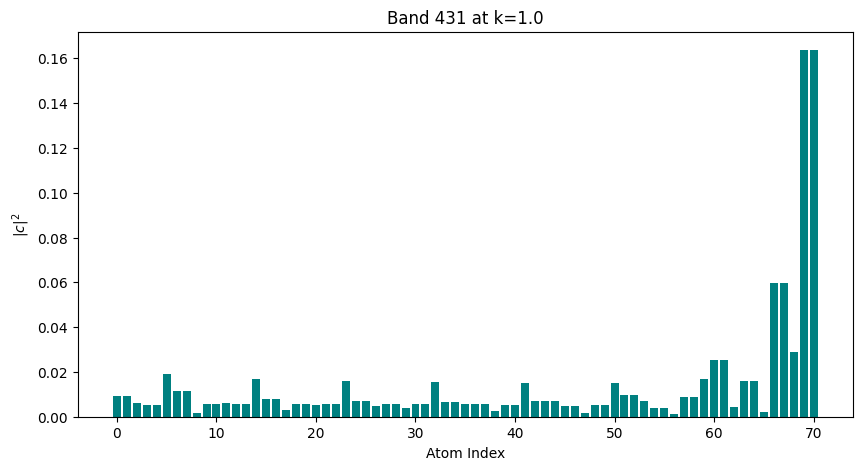

Total norm: 1.000000


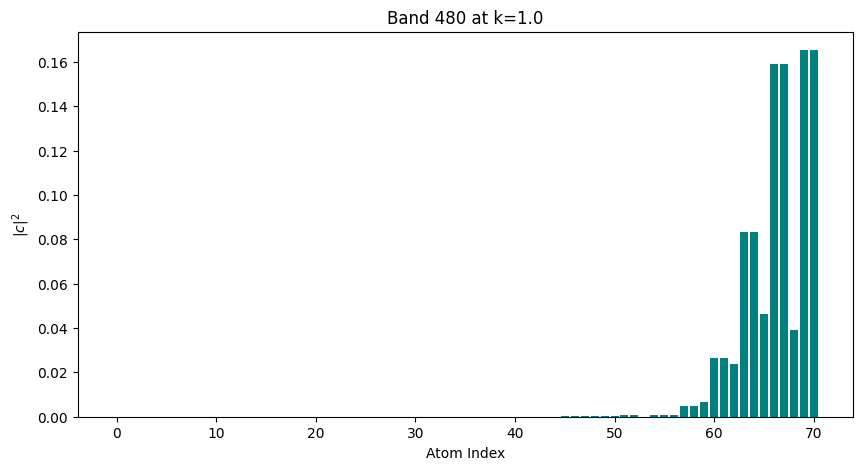

Total norm: 1.000000


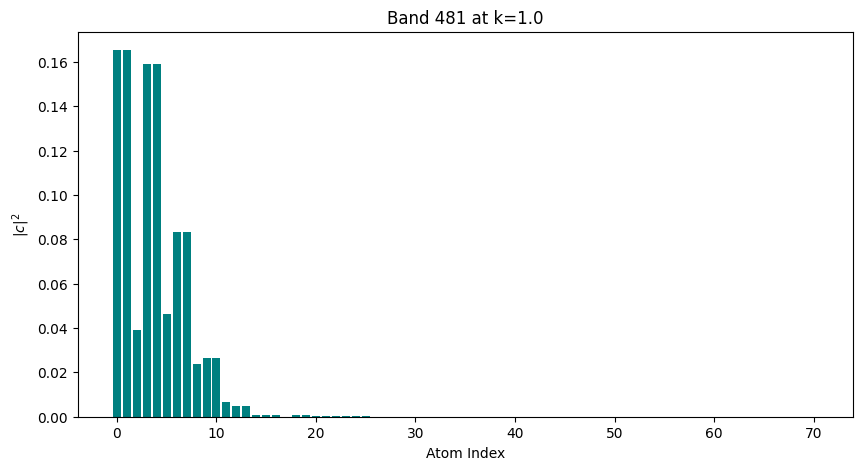

Total norm: 1.000000


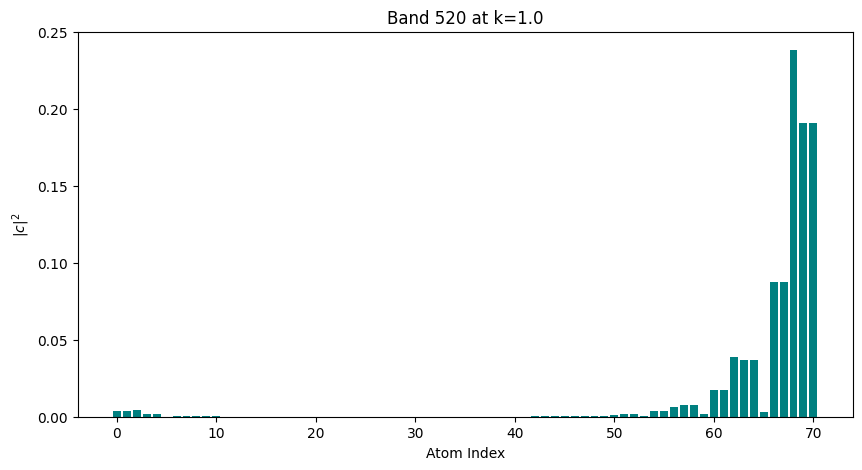

Total norm: 1.000000


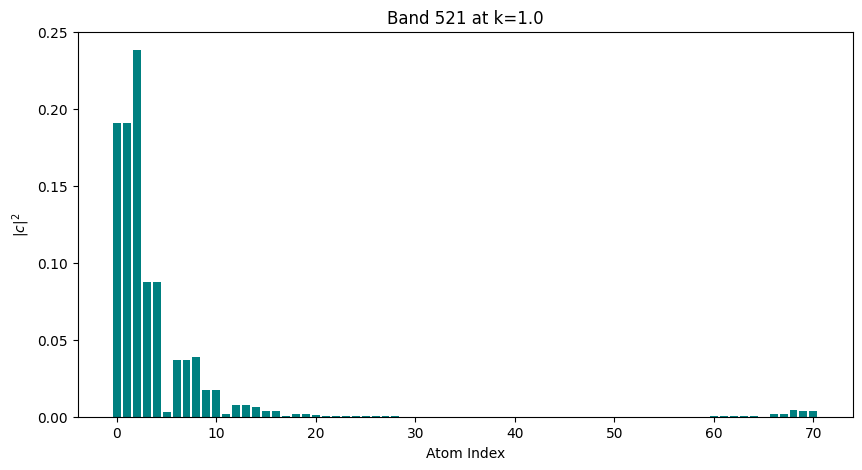

: 

In [ ]:
N_projections = len(tb_edge.coupled_states)
N_sites = len(tb_edge.sublattice_idxs)
N_bands = N_sites * N_projections

Psi_dict = tb_edge.band_structure_data["eigenvector_dict"]
for band in edge_bands:
    if band < 51:
        continue
    if band in edge_bands_top:
        k_target = 1.0
    elif band in edge_bands_bot_left:
        k_target = 1.51
    else:
        k_target = 1.61
    k_idx = np.argmin(np.abs(g.k_edge - k_target))
    Psi_k = Psi_dict[band][k_idx, :]
    total_norm = np.sum(np.abs(Psi_k)**2)
    print(f"Total norm: {total_norm:.6f}")
    n_atoms = len(tb_edge.sublattice_idxs)
    atomic_wavefunctions = {}
    atom_contributions = np.zeros(n_atoms)
    for i in range(n_atoms):
        start = i * N_projections
        end = start + N_projections
        orbital_block = Psi_k[start:end]  # Orbitals for atom i
        atom_contributions[i] = np.sum(np.abs(orbital_block)**2)
        atomic_wavefunctions[i] = Psi_k[start:end] 

    from matplotlib import pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.bar(range(n_atoms), atom_contributions, color='teal')
    plt.xlabel("Atom Index")
    plt.ylabel(f"$|c|^2$")
    # plt.xlim(0, 10)
    plt.title(f"Band {band} at k={np.abs(g.k_edge[k_idx]):.1f}")
    plt.show()